# Packages

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import wasserstein_distance

# Metropolis Hastings MCMC


In [ ]:
#Created on Fri Jun 30 13:24:01 2023
#@author: hmv
#Metropolis Hastings Markov Chain Monte Carlo

def target_distribution(x, mean, cov, dim, k=0):
    if dim == 1:
        mean = mean[k]
        cov = cov[k][k]

    return stats.multivariate_normal.pdf(x, mean = mean, cov=cov)
    #return 0.5*np.exp(-(x + 2)**2 / 2) / np.sqrt(2 * np.pi) + 0.5*np.exp(-(x -2)**2 / 2) / np.sqrt(2 * np.pi)
    #return np.exp(-x**2 / 2)

def proposal_distribution(x, step_size, dim):
    #return np.random.normal(x, step_size)
    return np.random.multivariate_normal(x, np.diag([step_size] * dim))

def acceptance_probability(current_x, proposed_x, dim):
    mean = np.array([0,2])
    cov=np.array([[1,0],[0,5]])
    numerator = target_distribution(proposed_x, mean, cov, dim)
    denominator = target_distribution(current_x, mean, cov, dim)
    #print(numerator / denominator)
    return min(1, numerator / denominator)


def metropolis_hastings(n_iterations, initial_x, step_size, dim):
    current_x = initial_x
    samples = [current_x]
    samples_x0 = []
    samples_x1 = []

    for i in range(n_iterations):
        # Generate a proposal sample
        proposed_x = proposal_distribution(current_x, step_size, dim)


        # Calculate the acceptance probability
        acceptance_prob = acceptance_probability(current_x, proposed_x, dim)

        # Accept or reject the proposal
        if np.random.uniform(0, 1) < acceptance_prob:
            current_x = proposed_x

        # Add the current sample to the list
        samples.append(current_x)
        samples_x0.append(current_x[0])
        samples_x1.append(current_x[1])

    return samples, samples_x0, samples_x1


# Set the parameters

# Parameters
n_iterations = 10000
dim = 100
initial_x = np.zeros(dim)
step_size = 0.05
mean = np.zeros(dim)
cov= np.identity(dim)
# Run the Metropolis-Hastings algorithm
samples, samples_x0, samples_x1 = metropolis_hastings(n_iterations, initial_x, step_size, dim)


# Plot the samples and the target distribution
x = np.linspace(-6, 6, 200)
y = np.linspace(-6, 6, 200)

#plt.hist(samples_x0[2000:], bins=200, density=True, alpha=0.5, label='Samples')
#plt.hist(samples_x1[2000:], bins=200, density=True, alpha=0.5, label='Samples')
#plt.plot(x, target, color='red', label='Target Distribution')
#plt.xlabel('x')
#plt.ylabel('Density')
#plt.legend()
#ply.show()

NameError: ignored

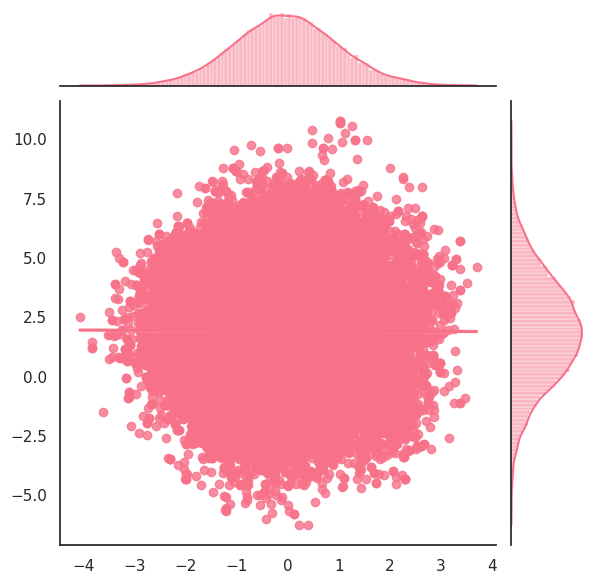

In [ ]:
g=sns.jointplot(x=samples_x0,y=samples_x1,kind='reg')
plt.show()

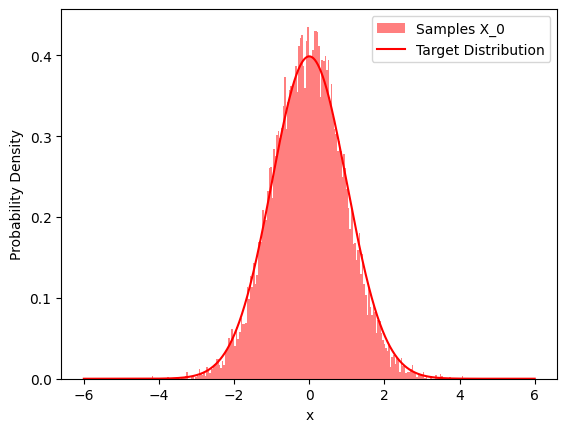

In [ ]:
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color= 'red', alpha=0.5, label='Samples X_0')
plt.plot(x, target, color='red', label='Target Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

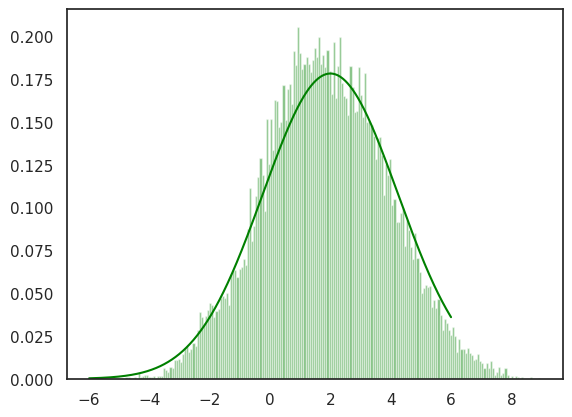

In [ ]:
cov=np.array([[1,0],[0,5]])
target1 = target_distribution(x, mean, cov, 1, 1)
plt.hist(samples_x1[int(n_iterations/2):], bins=200, density=True, color= 'green', alpha=0.5, label='Samples X1')
plt.plot(y, target1, color='green', label='Target Distribution')

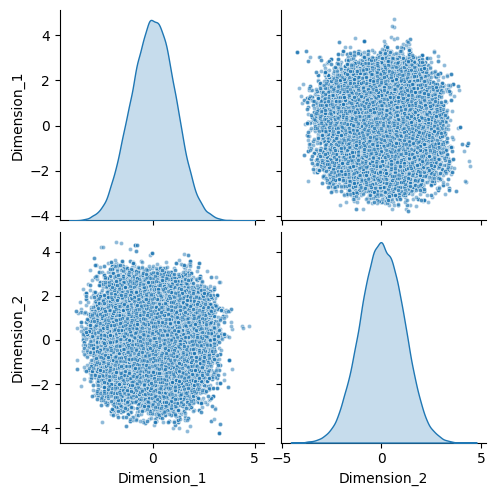

In [ ]:

def target_distribution(x):
    #return 0.5*np.exp(-(x + 2)**2 / 2) / np.sqrt(2 * np.pi) + 0.5*np.exp(-(x -2)**2 / 2) / np.sqrt(2 * np.pi)
    return np.exp(-x**2 / 2)

def proposal_distribution(x, step_size):
    #return np.random.normal(x, step_size)
    return np.random.multivariate_normal(x, np.diag(step_size))

def acceptance_probability(current_x, proposed_x):
    numerator = target_distribution(proposed_x)
    denominator = target_distribution(current_x)
    return np.minimum(1, numerator / denominator)

def metropolis_hastings(n_iterations, initial_x, step_size):
    current_x = initial_x
    samples = [current_x]

    total = 0
    for i in range(n_iterations):
        # Generate a proposal sample
        proposed_x = proposal_distribution(current_x, step_size)


        # Calculate the acceptance probability
        acceptance_prob = acceptance_probability(current_x, proposed_x)

        # Accept or reject the proposal
        if np.all(np.random.uniform(0, 1) < acceptance_prob):
            current_x = proposed_x

        # Add the current sample to the list
        samples.append(current_x)


    return samples

def plot_samples(samples):
    df = pd.DataFrame(samples, columns=[f'Dimension_{i+1}' for i in range(len(samples[0]))])

    # Create a pair plot using seaborn
    sns.pairplot(df, diag_kind='kde', markers='.', plot_kws={'alpha': 0.5})
    plt.show()


# Set the parameters

n_dimensions = 2
n_iterations = 100000
initial_x = np.random.randn(n_dimensions)  # Random initial point in the high-dimensional space

# Set a smaller step size
smaller_step_size = 0.2
step_size = np.full(n_dimensions, smaller_step_size)

# Run the Metropolis-Hastings algorithm
samples = metropolis_hastings(n_iterations, initial_x, step_size)

plot_samples(samples)




# Unadjusted Langevin Algorithm

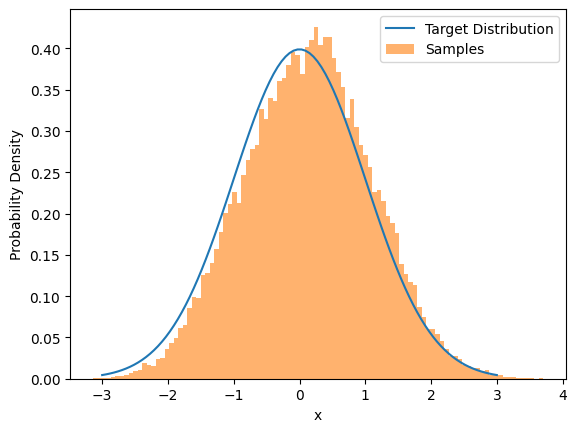

In [ ]:
###Created on Mon Jul  3 20:01:19 2023
##@author: hmv
#Langevin MCMC

# Target distribution (unnormalized)
def target_distribution(x):
    return np.exp(-x**2 / 2) # * np.sin(3*x)

# Gradient of the log probability distribution
def log_prob_gradient(x):
    return x  #3*np.cos(3*x)

# Langevin Monte Carlo algorithm
def langevin_mcmc(num_samples, step_size):
    x_samples = np.zeros(num_samples)

    for i in range(1,num_samples):
        # Update step
        x_current = x_samples[i-1]
        noise = np.random.normal(0, np.sqrt(2 * step_size))
        x_samples[i]= x_current - step_size * log_prob_gradient(x_current) + noise


    return x_samples

# Parameters
num_samples = 100000
step_size = 0.01

# Run Langevin MCMC
samples = langevin_mcmc(num_samples, step_size)

# Plotting
x = np.linspace(-3, 3, 100)
target = target_distribution(x)
plt.plot(x, target/np.sqrt(2*np.pi), label='Target Distribution')
plt.hist(samples[int(num_samples/2):], bins=100, density=True, label='Samples', alpha=0.6)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# Metropolis Adjusted Langevin Algorithm


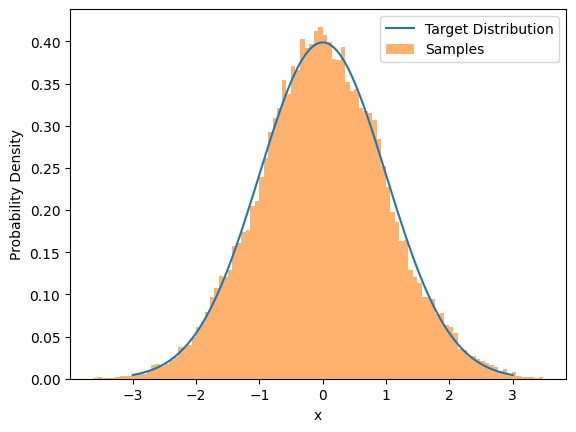

In [ ]:

# Target distribution (unnormalized)
def target_distribution(x):
    return np.exp(-x**2 / 2) #* np.sin(3*x)

# Gradient of the log probability distribution
def log_prob_gradient(x):
    return x #+ 3*np.cos(3*x)

def acceptance_probability(current_x, proposed_x):
    acceptance_prob = (target_distribution(proposed_x)/target_distribution(current_x)) * ((np.exp((-0.25* (1/step_size)) * (current_x - proposed_x + step_size*log_prob_gradient(proposed_x))**2)) / (np.exp((-0.25* (1/step_size)) * (proposed_x - current_x + step_size * log_prob_gradient(current_x))**2)) )
    return min(1, acceptance_prob)
    #acceptance_prob = (target_distribution(x_proposed)/target_distribution(x_current) * np.exp(-0.5 * (x_proposed - x_current)**2 / step_size))
    #acceptance_prob = (target_distribution(x_proposed)/target_distribution(x_current)) * ((np.exp((-0.25* (1/step_size)) * (x_current - x_proposed + step_size*log_prob_gradient(x_proposed))**2)) / (np.exp((-0.25* (1/step_size)) * (x_proposed - x_current + step_size * log_prob_gradient(x_current))**2)) )
    #acceptance_prob = min(1, acceptance_prob)


# Langevin Monte Carlo algorithm
def langevin_mcmc(num_samples, step_size):
    x_samples = np.zeros(num_samples)

    for i in range(1,num_samples):
        # Update step
        x_current = x_samples[i-1]
        noise = np.random.normal(0, np.sqrt(2 * step_size))
        x_proposed = x_current - step_size * log_prob_gradient(x_current) + noise

        # Metropolis-Hastings acceptance step
        acceptance_prob = acceptance_probability(x_current, x_proposed)

        if np.random.uniform() < acceptance_prob:
            x_current = x_proposed

        x_samples[i] = x_current

    return x_samples

# Parameters
num_samples = 100000
step_size = 0.01

# Run Langevin MCMC
samples = langevin_mcmc(num_samples, step_size)

# Plotting
x = np.linspace(-3, 3, 100)
target = target_distribution(x)
plt.plot(x, target/(np.sqrt(2*np.pi)), label='Target Distribution')
plt.hist(samples[int(num_samples/2):], bins=100, density=True, label='Samples', alpha=0.6)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# High Dimensional ULA

In [ ]:
# Target distribution
def target_distribution(x, mean, cov, dim, k=0):
    if dim == 1:
        mean = mean[k]
        cov = cov[k][k]
    return stats.multivariate_normal.pdf(x, mean = mean, cov=cov)

# Gradient of the log probability distribution
def log_prob_gradient(x, mean, cov, dim, k=0):
    #x = np.array(x)
    #mean = np.array(mean)

    #logg = -0.5 * np.transpose(x-mean) * cov * (x - mean) - 0.5 * dim * np.log(2*np.pi)
    #log_px = np.log(target_distribution(x, mean, cov, dim))
    #print("log gra:",logg)

    #gradient = np.gradient(logg)
    #log_px_gradient = nd.Gradient(target_distribution(x, mean, cov, dim))([x])
    #gradient = np.dot(np.linalg.inv(cov), (x - mean))
    gradient = (np.linalg.solve(cov, (x - mean)))

    return gradient


# Langevin Monte Carlo algorithm
def langevin_mcmc(n_iterations, step_size, mean, cov, dim, k=0):
    samples_x = []
    samples_x0 = []
    samples_x1 = []
    initial_x = np.zeros(dim)
    x_current = initial_x
    #x_samples = np.zeros((num_samples, dim))

    for i in range(1,n_iterations):


        # Generate noise from a multivariate normal distribution
        noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=np.identity(dim))

        gradient = log_prob_gradient(x_current, mean, cov, dim)

        initial_x = (x_current - step_size* 0.5 * gradient + np.sqrt(step_size)*noise)

        samples_x.append(initial_x)
        samples_x0.append(initial_x[0])
        samples_x1.append(initial_x[1])


        # Update step
        x_current = initial_x


    return samples_x, samples_x0, samples_x1


In [ ]:
# Parameters
n_iterations = 10000
dim = 100
initial_x = np.zeros(dim)
step_size = 0.05
mean = np.zeros(dim)
cov= np.identity(dim)


In [ ]:
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)

In [ ]:
# Plotting
x = np.linspace(-3, 3, 800)
y = np.linspace(-10, 10, 800)


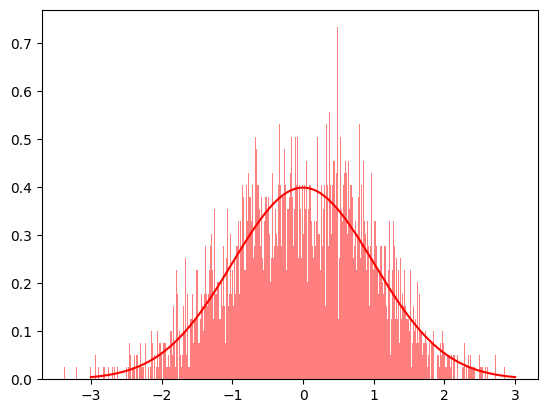

In [ ]:
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=800, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
plt.show()

In [ ]:
plt.hist(samples_x1[int(n_iterations/2):], bins=800, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(y, target, color='red', label='Target Distribution')
plt.show()

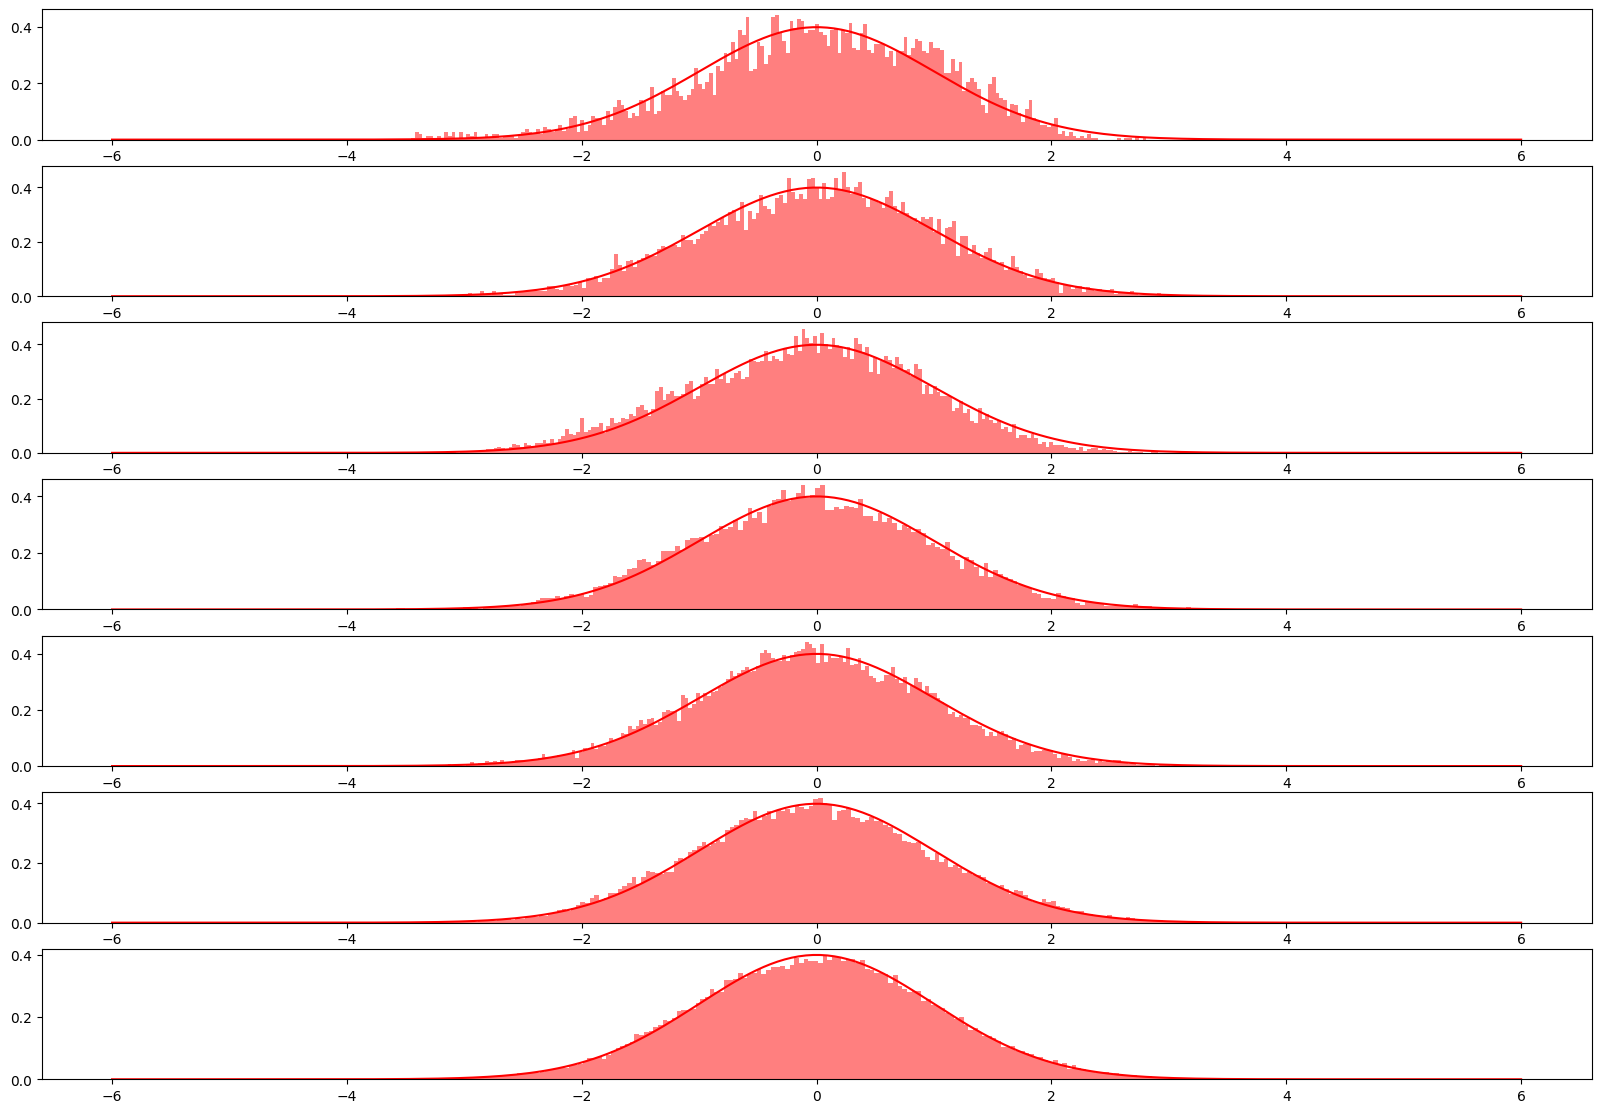

In [ ]:
fig1 = plt.figure(figsize=(20,20))

fig1.add_subplot(10,1,1)
#plt.subplot(10, 1, 1)
n_iterations = 10000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('10000 iterations')

fig1.add_subplot(10,1,2)
n_iterations = 20000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('20000 iterations')

fig1.add_subplot(10,1,3)
n_iterations = 30000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig1.add_subplot(10,1,4)
n_iterations = 40000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig1.add_subplot(10,1,5)
n_iterations = 50000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig1.add_subplot(10,1,6)
n_iterations = 100000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig1.add_subplot(10,1,7)
n_iterations = 200000
# Run Langevin MCMC
samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')




In [ ]:
fig1.savefig('ula.png')

KeyboardInterrupt: ignored

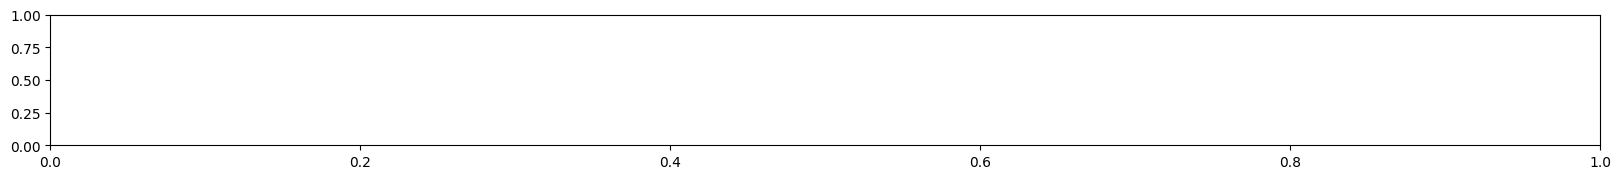

In [ ]:
fig = plt.figure(figsize=(20,20))
i = 1
while i < 11:

    fig.add_subplot(10,1,i)
    n_iterations = i*10000
    # Run Langevin MCMC
    samples_x, samples_x0, samples_x1 = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
    x = np.linspace(-4, 4, 800)
    target = target_distribution(x, mean, cov, 1, 0)
    plt.hist(samples_x0[int(n_iterations/2):], bins=800, density=True, color = 'red', alpha=0.5, label='Samples X0')
    plt.plot(x, target, color='red', label='Target Distribution')
    #plt.title('30000 iterations')
    i+=1

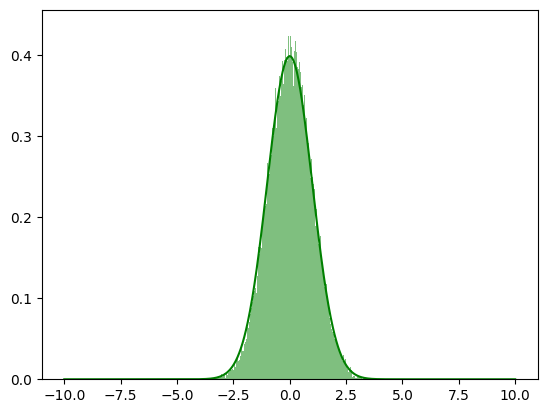

In [ ]:
target1 = target_distribution(y, mean, cov, 1, 1)
plt.hist(samples_x1[int(n_iterations/2):], bins=200, density=True, color= 'green', alpha=0.5, label='Samples X1')
plt.plot(y, target1, color='green', label='Target Distribution')

# High Dimensional MALA

In [ ]:
# Target distribution
def target_distribution(x, mean, cov, dim, k=0):
    if dim == 1:
        mean = mean[k]
        cov = cov[k][k]
    return stats.multivariate_normal.pdf(x, mean = mean, cov=cov)

# Gradient of the log probability distribution
def log_prob_gradient(x, mean, cov, dim, k=0):
    x = np.array(x)
    mean = np.array(mean)

    #logg = -0.5 * np.transpose(x-mean) * cov * (x - mean) - 0.5 * dim * np.log(2*np.pi)
    #log_px = np.log(target_distribution(x, mean, cov, dim))
    #print("log gra:",logg)

    #gradient = np.gradient(logg)
    #log_px_gradient = nd.Gradient(target_distribution(x, mean, cov, dim))([x])
    #gradient = np.dot(np.linalg.inv(cov), (x - mean))
    gradient = (np.linalg.solve(cov, (x - mean)))

    return gradient

def acceptance_probability(current_x, proposed_x, mean, cov, dim, k=0):
    acceptance_prob = (target_distribution(proposed_x, mean, cov, dim)/target_distribution(current_x, mean, cov, dim))
    conditional_curr_proposed = np.exp((-0.25* (1/step_size)) * np.linalg.norm(current_x - proposed_x + step_size*log_prob_gradient(proposed_x, mean, cov, dim))**2) / np.exp((-0.25* (1/step_size)) * np.linalg.norm(proposed_x - current_x + step_size * log_prob_gradient(current_x, mean, cov, dim))**2)
    acceptance_prob = acceptance_prob * conditional_curr_proposed
    #print(acceptance_prob)
    return min(1, acceptance_prob)


# Langevin Monte Carlo algorithm
def langevin_mcmc(n_iterations, step_size, mean, cov, dim, k=0):
    samples_x_mala = []
    samples_x0_mala = []
    samples_x1_mala = []

    initial_x = np.zeros(dim)#[0.1 , 0.2]
    x_current = initial_x
    #x_samples = np.zeros((num_samples, dim))

    for i in range(1,n_iterations):


        # Generate noise from a multivariate normal distribution
        noise = np.random.multivariate_normal(mean=np.zeros(dim), cov=np.identity(dim))

        gradient = log_prob_gradient(x_current, mean, cov, dim)

        initial_x = (x_current - step_size* 0.5 * log_prob_gradient(x_current, mean, cov, dim) + np.sqrt(step_size)*noise)


        # Metropolis-Hastings acceptance step
        acceptance_prob = acceptance_probability(x_current, initial_x, mean, cov, dim)
        if np.random.uniform() < acceptance_prob:
            # Update step
            x_current = initial_x

        samples_x_mala.append(x_current)
        samples_x0_mala.append(x_current[0])
        samples_x1_mala.append(x_current[1])


    return samples_x_mala, samples_x0_mala, samples_x1_mala

In [ ]:
# Parameters
n_iterations = 10000
dim = 100
initial_x = np.zeros(dim) #[0.1 , 0.2]
step_size = 0.05
mean = np.zeros(dim) #np.array([0,2])
cov= np.identity(dim) #np.array([[1,0],[0,5]])

In [ ]:
#Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)


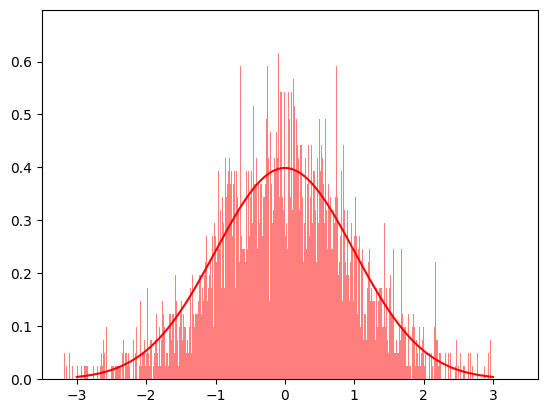

In [ ]:
# Plotting
x = np.linspace(-3, 3, 800)
y = np.linspace(-10, 10, 800)
target_mala = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=800, density=True, color= 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target_mala, color='red', label='Target Distribution MALA')
plt.show()


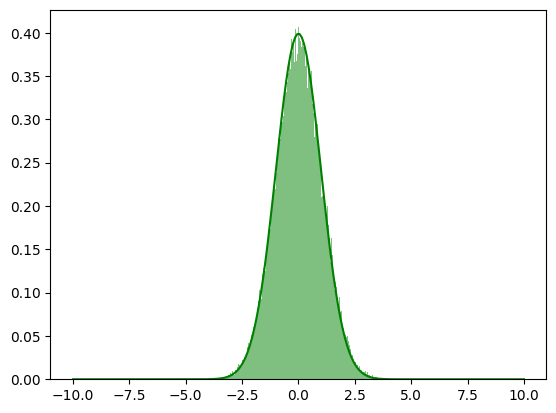

In [ ]:
target1_mala1 = target_distribution(y, mean, cov, 1, 1)
plt.hist(samples_x1[int(n_iterations/2):], bins=800, density=True, color= 'green', alpha=0.5, label='Samples X1')
plt.plot(y, target1_mala1, color='green', label='Target Distribution')

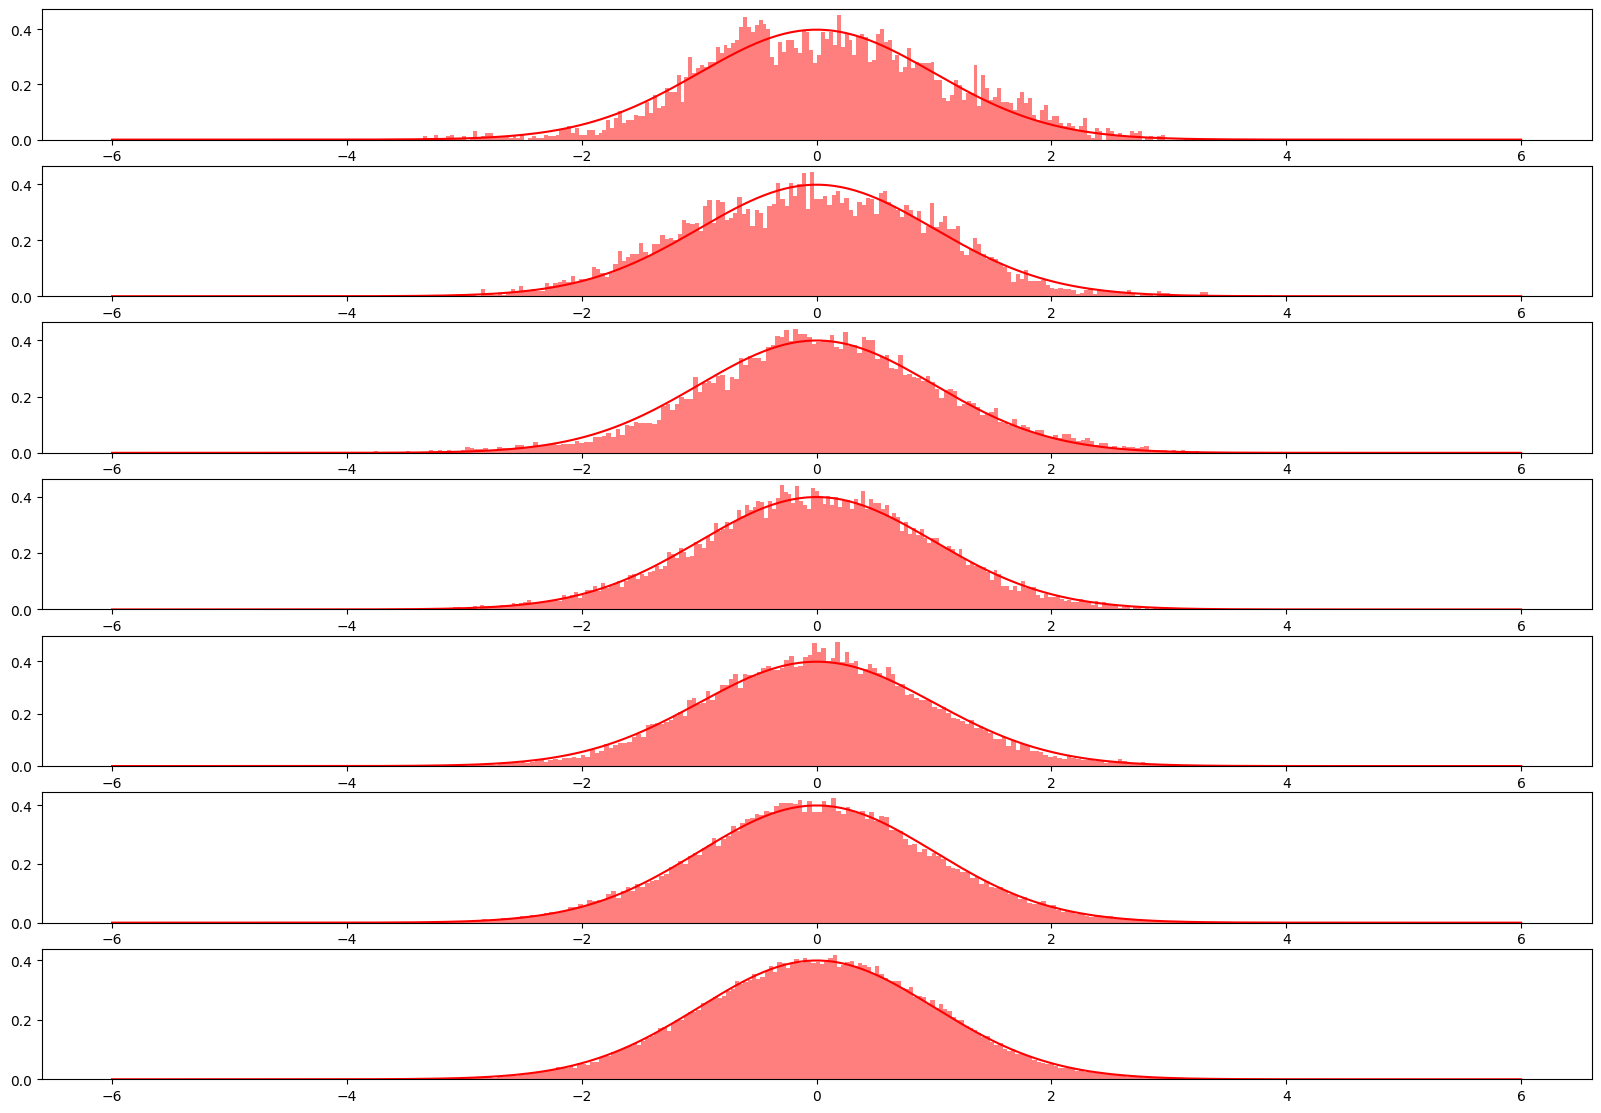

In [ ]:
fig = plt.figure(figsize=(20,20))

fig.add_subplot(10,1,1)
#plt.subplot(10, 1, 1)
n_iterations = 10000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('10000 iterations')

fig.add_subplot(10,1,2)
n_iterations = 20000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('20000 iterations')

fig.add_subplot(10,1,3)
n_iterations = 30000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig.add_subplot(10,1,4)
n_iterations = 40000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig.add_subplot(10,1,5)
n_iterations = 50000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig.add_subplot(10,1,6)
n_iterations = 100000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')

fig.add_subplot(10,1,7)
n_iterations = 200000
# Run Langevin MCMC
samples_x_mala, samples_x0_mala, samples_x1_mala = langevin_mcmc(n_iterations, step_size, mean, cov, dim)
x = np.linspace(-6, 6, 200)
target = target_distribution(x, mean, cov, 1, 0)
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=200, density=True, color = 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution')
#plt.title('30000 iterations')



In [ ]:
fig.savefig('mala.png')

In [ ]:
n_iterations = 50000
x = np.linspace(-6,6,400)
plt.subplot(1,2,1)
plt.title("ULA")
plt.hist(samples_x0[int(n_iterations/2):], bins=400, density=True, color= 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target, color='red', label='Target Distribution ULA')

plt.subplot(1,2,2)
plt.title("MALA")
plt.hist(samples_x0_mala[int(n_iterations/2):], bins=400, density=True, color= 'red', alpha=0.5, label='Samples X0')
plt.plot(x, target_mala, color='red', label='Target Distribution MALA')

plt.show()

# Graph in Paper

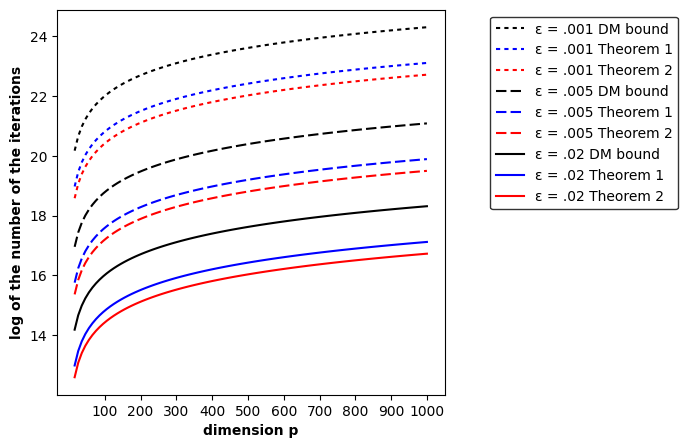

In [ ]:
def theorem3(p, epsilon):
    #return (np.log(np.power((epsilon-33*np.sqrt(p)/100),2)) - np.log(121*np.power(p,2)/100))/np.log(0.81)
    M = 20
    m = 10
    return np.log((1.65**2)*(M**2)*p/((m**2)*(epsilon**2)))

def theorem4(p, epsilon):
    M = 20
    m = 10
    K1 = np.ceil(np.log((p+p/m)/np.sqrt(p)) + np.log(m/M) + 0.5 * np.log(M+m))/np.log(1+2*m/(M-m))
    return np.log(((3.5**2)*(M**2)*p/((epsilon**2)*(m**2))-M-m)*3/(2*m) + K1)

def theorem5(p, epsilon):
    M = 20
    m = 10
    return np.log((4*M*p*((m+M)**2)/m)*(1+1/(np.power((p+p/m),2)))/(m*M*(epsilon**2)))
    #return (np.log(np.power((epsilon-123*p/1000),2)) - 2*np.log(242*np.power(p,2)/100))/np.log(np.power(0.067,2))


fig2 = plt.figure(figsize = (5,5))
fig2.add_subplot(1,1,1)
p = np.linspace(16, 1000, 100)

custom_x_ticks = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
plt.plot(p, theorem5(p, 0.001), color = 'black', linestyle = 'dashed', dashes=(2, 2), label = '\u03B5 = .001 DM bound')
plt.plot(p, theorem3(p, 0.001), color = 'blue', linestyle = 'dashed', dashes=(2, 2), label = '\u03B5 = .001 Theorem 1')
plt.plot(p, theorem4(p, 0.001), color = 'red', linestyle = 'dashed', dashes=(2, 2), label = '\u03B5 = .001 Theorem 2')


plt.plot(p, theorem5(p, 0.005), color = 'black', linestyle = 'dashed', dashes=(5, 2), label = '\u03B5 = .005 DM bound')
plt.plot(p, theorem3(p, 0.005), color = 'blue', linestyle = 'dashed', dashes=(5, 2), label = '\u03B5 = .005 Theorem 1')
plt.plot(p, theorem4(p, 0.005), color = 'red', linestyle = 'dashed', dashes=(5, 2), label = '\u03B5 = .005 Theorem 2')


plt.plot(p, theorem5(p, 0.02), color = 'black', label = '\u03B5 = .02 DM bound')
plt.plot(p, theorem3(p, 0.02), color = 'blue', label = '\u03B5 = .02 Theorem 1')
plt.plot(p, theorem4(p, 0.02), color = 'red', label = '\u03B5 = .02 Theorem 2')

plt.xticks(custom_x_ticks, custom_x_ticks)
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1), frameon=True, edgecolor='black')
plt.xlabel('dimension p', fontweight='bold')
plt.ylabel('log of the number of the iterations', fontweight='bold')
plt.show()

fig2.savefig('graph_paper.png')
